# Image segmenter
An 2D image is a single or multiple arrays. Each array corresponds to Red, Green, or Blue in an image, where each cell corresponds to the color brightness at a given location. This collection of arrays, and all their pixels, comprises the image in totality. The purpose of this script is to randomly or regementally split an image array into small chunks that can be can be used in subsequent applications.

### Libraries

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
from skimage import io
import random

## First let's import a cool test image

In [116]:
test_image = io.imread('/home/unitx/wabbit_playground/nn/minecraft/archering_2375.png')

## Let's look at it...

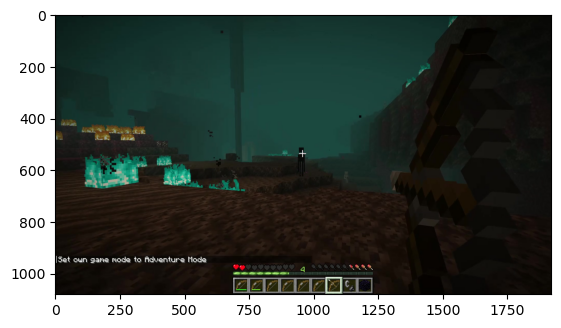

In [117]:
plt.imshow(test_image)
plt.show()

## Looks cool... now let's split it up by color channel

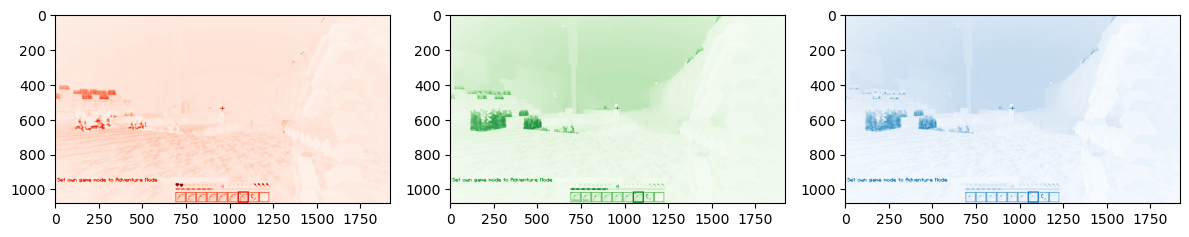

In [118]:
test_reds = np.array(test_image[:, :, 0]) / 255
test_greens = np.array(test_image[:, :, 1]) / 255
test_blues = np.array(test_image[:, :, 2]) / 255

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(test_reds, cmap='Reds')
plt.subplot(1, 3, 2)
plt.imshow(test_greens, cmap='Greens')
plt.subplot(1, 3, 3)
plt.imshow(test_blues, cmap='Blues')
plt.tight_layout()
plt.show()

## Woahhhh okay so now that we have arrays, let's see how we can fragment them

### Fragmenter 1: Nice and Tidy
The following fragmenter takes an array and split's it up nicely. Given the desired fragment size *n*, we will split the image into *nxn* fragments starting from index (0,0) to index (X-1,Y-1) where X is the pixel width of the image and Y is the pixel height. There is no overlap here and data may be lost to keep the fragment array size consistant.

(18, 300, 300)


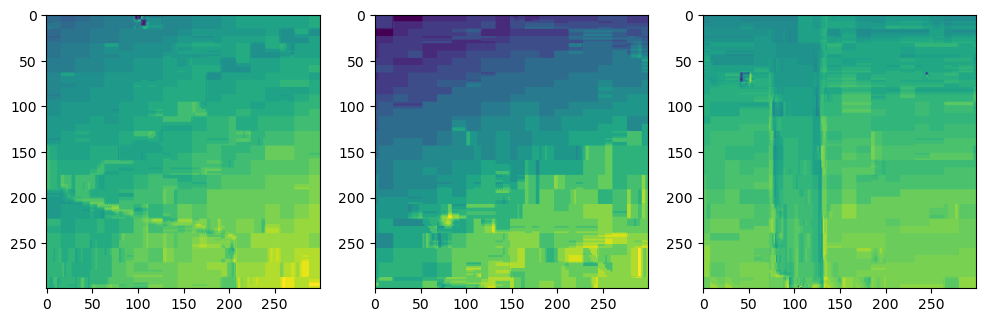

In [119]:
def fragmenter_one(image, fragment_size):
    height, width = image.shape
    fragments = []
    num_yits = height // fragment_size
    num_xits = width // fragment_size
    for j in range(num_yits):
        for i in range(num_xits):
            y = j*fragment_size
            x = i*fragment_size
            fragment = image[y:y+fragment_size, x:x+fragment_size]
            fragments.append(fragment)
    return fragments

# print(test_reds.shape)
frags  = fragmenter_one(test_reds, 300)
print(np.shape(frags))
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(frags[0])
plt.subplot(1, 3, 2)
plt.imshow(frags[1])
plt.subplot(1, 3, 3)
plt.imshow(frags[2])
plt.show()

### Fragmenter 2: Random Breaks
The following fragmenter takes an array and selects random locations to fragment. Given the desired fragment size *n*, and the number of desired fragments *f*, we will pull *f* number *nxn* fragmentsfrom the image. There may be data overlap because the fragments are randomized.

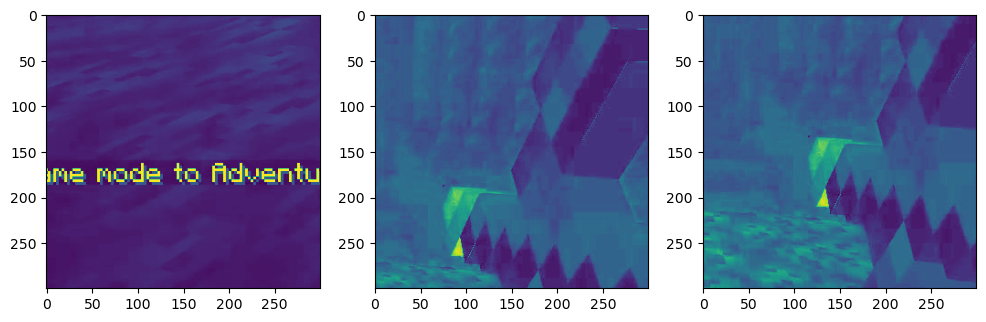

In [120]:
def fragmenter_two(image, fragment_size, fragment_number):
    height, width = image.shape
    fragments = []
    for i in range(fragment_number):
        random_y = random.randint(0,height-fragment_size+1)
        random_x = random.randint(0,width-fragment_size+1)
        fragment = image[random_y:random_y+fragment_size, random_x:random_x+fragment_size]
        fragments.append(fragment)
    return fragments

frags  = fragmenter_two(test_reds, 300, 4)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(frags[0])
plt.subplot(1, 3, 2)
plt.imshow(frags[1])
plt.subplot(1, 3, 3)
plt.imshow(frags[2])
plt.show()

## That's a good start! How about we try something similar, now fragmenting across all arrays simultaneously.

### Fragmenter Alpha: Cleancut Splits for All
This function aims to split all arrays simultaneously, in a similar way to Fragmenter One. Each Row should correspond to the Reds, Greens, Blues of each fragment.

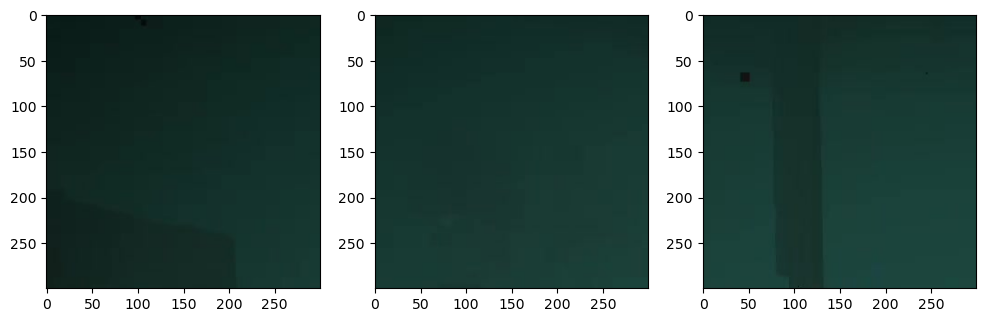

In [121]:
def fragmenter_alpha(image, fragment_size):
    height, width, _ = image.shape

    num_yits = height // fragment_size
    num_xits = width // fragment_size

    fragments = []
    for j in range(num_yits):
        for i in range(num_xits):
            y = j*fragment_size
            x = i*fragment_size
            fragment = image[y:y+fragment_size, x:x+fragment_size, :]
            fragments.append(fragment)
    return fragments

frags  = fragmenter_alpha(test_image, 300)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(frags[0])
plt.subplot(1, 3, 2)
plt.imshow(frags[1])
plt.subplot(1, 3, 3)
plt.imshow(frags[2])
plt.show()

## Fragmenter Beta: Widespread Random Splits
This function aims to split all arrays simultaneously like that of Fragmenter Two. Each Row should correspond to the Reds, Greens, and Blues

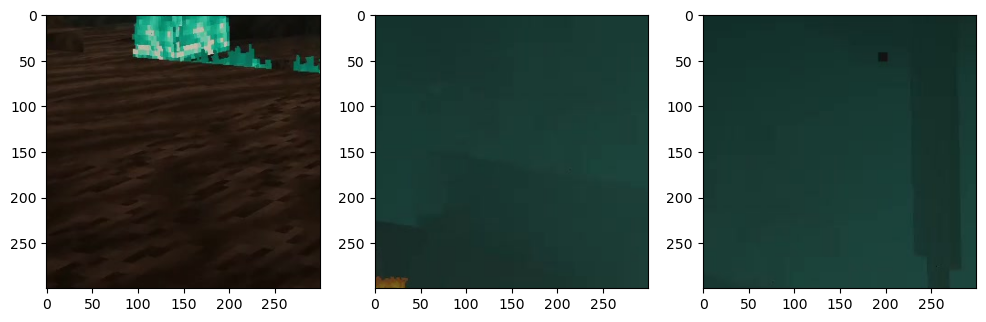

In [122]:
def fragmenter_beta(image, fragment_size, fragment_number):
    height, width, _ = image.shape
    fragments = []
    for i in range(fragment_number):
        random_y = random.randint(0,height-fragment_size+1)
        random_x = random.randint(0,width-fragment_size+1)
        fragment = image[random_y:random_y+fragment_size, random_x:random_x+fragment_size, :]
        fragments.append(fragment)
    return fragments

frags  = fragmenter_beta(test_image, 300, 4)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(frags[0])
plt.subplot(1, 3, 2)
plt.imshow(frags[1])
plt.subplot(1, 3, 3)
plt.imshow(frags[2])
plt.show()

## These Fragmenters Look Similar
It looks like there are only a few differences between both One/Alpha and Two/Beta. Let's see if we can get around that to make one function for each Tidy and Random approaches.

### Tidy Fragmenter: Neat Splitting of Single and Multi Channel Images
The *Tidy Fragmenter* combines the functionality of One and Alpha fragmenters. It generalizes the fragmenting of array across all sizes.

In [ ]:
def fragmenter_beta(image, fragment_size, fragment_number):
    if len(image.shape) == 2:
        
    height, width, _ = image.shape
    fragments = []
    for i in range(fragment_number):
        random_y = random.randint(0,height-fragment_size+1)
        random_x = random.randint(0,width-fragment_size+1)
        fragment = image[random_y:random_y+fragment_size, random_x:random_x+fragment_size, :]
        fragments.append(fragment)
    return fragments